<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/snr_calculator_Silas_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generalized Droop SNR Calculator — Colab Version

원본 `snr_calculator_Silas(3).py`의 `SNR_GD` 함수를 Google Colab에서 바로 실행하고, total WDM launch power에 따른 SNR을 그래프로 확인할 수 있도록 구성한 노트북입니다.

## 모델 입력과 출력

- 입력 `Ps`는 채널당 파워가 아니라 **전체 WDM launch power [W]**입니다. 내부에서 `P_ch = Ps / N_ch`로 변환됩니다.
- 출력 SNR은 linear scale입니다. `Lin2dB()`로 dB 변환합니다.
- `gamma_XT`는 코드 식에 직접 곱해지는 **linear crosstalk coefficient [1/km]**입니다. 누화를 제외하려면 `0`을 사용합니다.
- `D=17e-12`는 17 ps/(nm·km)를 s/(nm·km)로 바꾼 값입니다.
- Colab 기본 패키지인 NumPy와 Matplotlib만 사용하므로 별도 설치 셀이 필요 없습니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def Lin2dB(value_linear):
    with np.errstate(divide='ignore', invalid='ignore'):
        return 10.0 * np.log10(np.asarray(value_linear))

def Lin2dBm(value_W):
    with np.errstate(divide='ignore', invalid='ignore'):
        return 10.0 * np.log10(np.asarray(value_W) / 1e-3)

def dBm2Lin(value_dBm):
    return 1e-3 * 10.0 ** (np.asarray(value_dBm) / 10.0)

In [2]:
def SNR_GD(Ps, lamb, alpha, NF, N, gamma, Ltot, B, D, Rs,
           gamma_XT, l_FIFO, delta_f):
    """Calculate end-to-end SNR using the generalized droop model.

    Parameters use the units stated in the markdown cell above.
    The returned SNR has linear scale and follows the equations
    used in the supplied source code.
    """
    Ps = np.asarray(Ps, dtype=float)
    if np.any(Ps <= 0):
        raise ValueError('Ps must contain positive power values in watts.')
    if N < 1 or alpha <= 0 or B <= 0 or delta_f <= 0 or Rs <= 0:
        raise ValueError('N, alpha, B, delta_f, and Rs must be positive.')

    h = 6.62607015e-34                          # J·s
    c = 2.99792458e17                           # nm/s
    f = c / lamb                                # Hz
    N_ch = B / delta_f
    P_ch = Ps / N_ch
    alpha_lin = alpha / 4.343
    NF_lin = 10.0 ** (NF / 10.0)

    beta_2 = -D * lamb**2 / (2.0 * np.pi * c)  # s²/km

    # ASE droop
    alpha_span = alpha * Ltot / N + 2.0 * l_FIFO
    G_lin = 10.0 ** (alpha_span / 10.0)
    P_ASE = h * f * NF_lin * Rs * (G_lin - 1.0)
    chi_a = (1.0 + P_ASE / P_ch) ** (-1.0)

    # NLI and crosstalk droop
    L_eff = (1.0 - np.exp(-alpha_lin * Ltot / N)) / alpha_lin
    L_effa = 1.0 / alpha_lin
    asinh_arg = (
        np.pi**2 / 2.0 * np.abs(beta_2) * L_effa * Rs**2
        * N_ch ** (2.0 * Rs / delta_f)
    )
    alpha_NLI = (
        8.0 / 27.0 * gamma**2 * L_eff**2 * np.arcsinh(asinh_arg)
        / (np.pi * np.abs(beta_2) * L_effa * Rs**2)
    )
    SNR_1R_NLI = 1.0 / (alpha_NLI * P_ch**2)

    if gamma_XT == 0:
        SNR_1R = SNR_1R_NLI
    else:
        SNR_1R_XT = 1.0 / (gamma_XT * Ltot / N)
        SNR_1R = 1.0 / (1.0 / SNR_1R_NLI + 1.0 / SNR_1R_XT)

    chi_r = (1.0 + 1.0 / SNR_1R) ** (-1.0)
    return 1.0 / ((chi_a**(-1.0) * chi_r**(-1.0))**N - 1.0)

## 입력 파라미터 예제

아래 값은 코드 실행을 확인하기 위한 대표 예시입니다. 실제 케이블/광섬유 조건에 맞게 수정하십시오.

In [3]:
# Total WDM launch-power sweep
Ps_dBm = np.linspace(0.0, 30.0, 601)
Ps = dBm2Lin(Ps_dBm)

# Link and fiber parameters
lamb = 1550.0       # nm
alpha = 0.16        # dB/km
NF = 5.0            # dB
Ltot = 6000.0       # km
span_length = 80.0  # km
N = int(np.floor(Ltot / span_length))
gamma = 1.2         # 1/(W·km)
B = 4.0e12          # Hz
D = 17e-12          # s/(km·nm)
Rs = 32e9           # baud
gamma_XT = 0.0      # 1/km (linear); 0 disables XT
l_FIFO = 0.5        # dB per FIFO
delta_f = 50e9      # Hz

SNR_linear = SNR_GD(
    Ps, lamb, alpha, NF, N, gamma, Ltot, B, D, Rs,
    gamma_XT, l_FIFO, delta_f
)
SNR_dB = Lin2dB(SNR_linear)
best = int(np.nanargmax(SNR_linear))

print(f'Channels              : {B/delta_f:.0f}')
print(f'Repeaters/spans N     : {N}')
print(f'Optimal total power   : {Ps_dBm[best]:.3f} dBm')
print(f'Power per channel     : {Ps_dBm[best]-10*np.log10(B/delta_f):.3f} dBm/ch')
print(f'Maximum end-to-end SNR: {SNR_dB[best]:.3f} dB')

Channels              : 80
Repeaters/spans N     : 75
Optimal total power   : 16.150 dBm
Power per channel     : -2.881 dBm/ch
Maximum end-to-end SNR: 11.707 dB


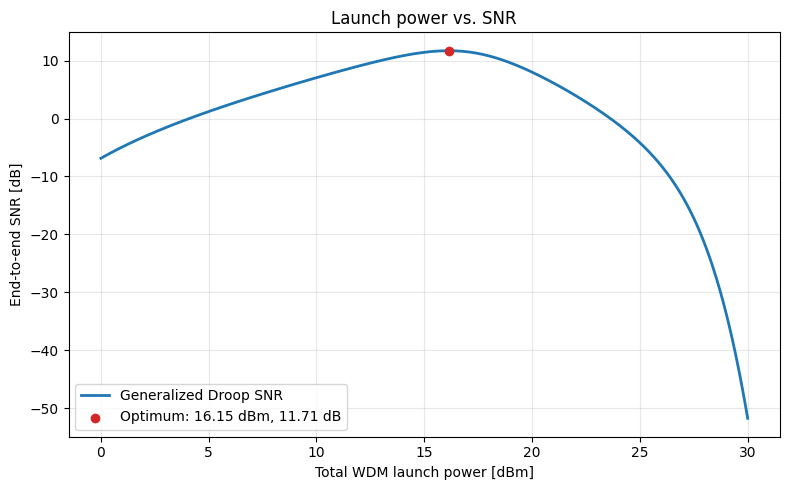

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(Ps_dBm, SNR_dB, lw=2, label='Generalized Droop SNR')
plt.scatter(Ps_dBm[best], SNR_dB[best], color='tab:red', zorder=3,
            label=f'Optimum: {Ps_dBm[best]:.2f} dBm, {SNR_dB[best]:.2f} dB')
plt.xlabel('Total WDM launch power [dBm]')
plt.ylabel('End-to-end SNR [dB]')
plt.title('Launch power vs. SNR')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Paper**

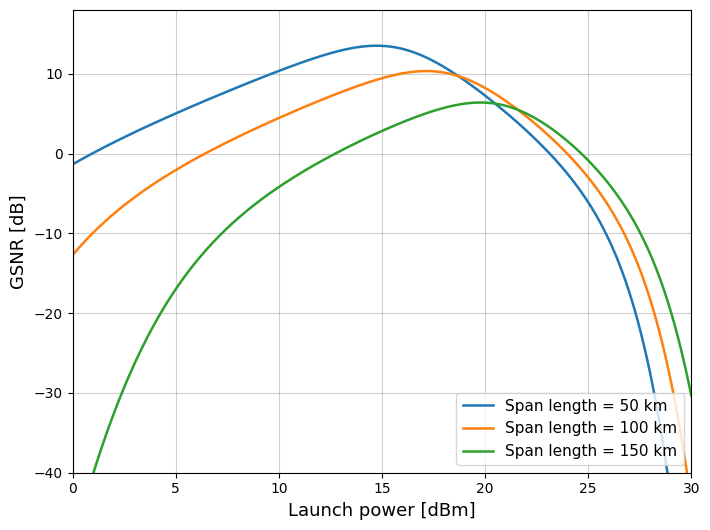

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Launch-power sweep
# ============================================================
# SNR_GD()의 Ps는 전체 WDM launch power [W]
Ps_dBm = np.linspace(0, 30, 601)
Ps = dBm2Lin(Ps_dBm)

# ============================================================
# 2. 공통 시스템 파라미터
# ============================================================
Ltot = 6000.0       # Total transmission distance [km]

lamb = 1550.0       # Wavelength [nm]
alpha = 0.16        # Fiber attenuation [dB/km]
NF = 5.0            # Amplifier noise figure [dB]
gamma = 1.2         # Nonlinear coefficient [1/(W·km)]

B = 4.0e12          # Total WDM bandwidth [Hz]
Rs = 32e9           # Symbol rate [baud]
delta_f = 50e9      # Channel spacing [Hz]

D = 17e-12          # Dispersion [s/(nm·km)]
gamma_XT = 0.0      # Crosstalk coefficient [1/km]
l_FIFO = 0.5        # FIFO loss [dB], one side

# 비교할 span length
span_lengths_km = [50.0, 100.0, 150.0]

# ============================================================
# 3. Span length별 GSNR 계산
# ============================================================
results = {}

plt.figure(figsize=(7.2, 5.4))

for span_length in span_lengths_km:

    # 각 span length에 대응하는 repeater/span 개수
    N = int(np.floor(Ltot / span_length))

    # Generalized Droop model 계산
    GSNR_linear = SNR_GD(
        Ps=Ps,
        lamb=lamb,
        alpha=alpha,
        NF=NF,
        N=N,
        gamma=gamma,
        Ltot=Ltot,
        B=B,
        D=D,
        Rs=Rs,
        gamma_XT=gamma_XT,
        l_FIFO=l_FIFO,
        delta_f=delta_f
    )

    GSNR_dB = Lin2dB(GSNR_linear)

    # 결과 저장
    results[span_length] = {
        "N": N,
        "GSNR_linear": GSNR_linear,
        "GSNR_dB": GSNR_dB
    }

    # 그래프 출력
    plt.plot(
        Ps_dBm,
        GSNR_dB,
        linewidth=1.8,
        label=f"Span length = {span_length:.0f} km"
    )

# ============================================================
# 4. 그래프 설정
# ============================================================
plt.xlabel("Launch power [dBm]", fontsize=13)
plt.ylabel("GSNR [dB]", fontsize=13)

plt.xlim(0, 30)
plt.ylim(-40, 18)

plt.xticks(np.arange(0, 31, 5))
plt.yticks(np.arange(-40, 11, 10))

plt.grid(True, alpha=0.6)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

In [6]:
for span_length in span_lengths_km:

    GSNR_dB = results[span_length]["GSNR_dB"]
    optimum_index = int(np.nanargmax(GSNR_dB))

    optimum_power_dBm = Ps_dBm[optimum_index]
    maximum_GSNR_dB = GSNR_dB[optimum_index]
    N = results[span_length]["N"]

    print(
        f"Span length = {span_length:5.0f} km | "
        f"N = {N:3d} | "
        f"Optimal power = {optimum_power_dBm:6.2f} dBm | "
        f"Maximum GSNR = {maximum_GSNR_dB:6.2f} dB"
    )

Span length =    50 km | N = 120 | Optimal power =  14.75 dBm | Maximum GSNR =  13.52 dB
Span length =   100 km | N =  60 | Optimal power =  17.15 dBm | Maximum GSNR =  10.35 dB
Span length =   150 km | N =  40 | Optimal power =  19.80 dBm | Maximum GSNR =   6.40 dB
